<a href="https://colab.research.google.com/github/mgb1112/Data-Science-For-Public-Health/blob/main/hw4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving opioid.db to opioid.db


So far, I have imported the proper functions/libraries for the assignment as well as imported the opioid.db created using sqlite3.

In [ ]:
# connect to database
conn = sqlite3.connect("opioid.db")

# print first five rows from population table
query = "SELECT BUYER_COUNTY, BUYER_STATE, STATE, COUNTY, year, population FROM population LIMIT 5;"
population_df = pd.read_sql(query, conn)
print(population_df)

# print missing countyfips data in annual table
query = "SELECT * FROM annual WHERE countyfips = 'NA' LIMIT 10;"
missing_df = pd.read_sql(query, conn)
print(missing_df)

# check for missing countyfips data outside Puerto Rico
query = "SELECT * FROM annual WHERE countyfips = 'NA' AND BUYER_STATE != 'PR' LIMIT 10;"
missing_non_pr_df = pd.read_sql(query, conn)
print(missing_non_pr_df)

# update countyfips for Montgomery, AR
update_query = """
UPDATE annual
SET countyfips = '05097'
WHERE BUYER_STATE = 'AR' AND BUYER_COUNTY = 'MONTGOMERY';
"""
conn.execute(update_query)
conn.commit()

# verify update
query = "SELECT * FROM annual WHERE BUYER_STATE = 'AR' AND BUYER_COUNTY = 'MONTGOMERY';"
montgomery_df = pd.read_sql(query, conn)
print(montgomery_df)

# delete rows where countyfips is missing
delete_query = "DELETE FROM annual WHERE countyfips = 'NA';"
conn.execute(delete_query)
conn.commit()

# create new table land_area
create_land_area_query = "CREATE TABLE land_area AS SELECT Areaname, STCOU, LND110210D FROM land;"
conn.execute(create_land_area_query)
conn.commit()

# rename column STCOU to countyfips
alter_query = "ALTER TABLE land_area RENAME COLUMN STCOU TO countyfips;"
conn.execute(alter_query)
conn.commit()

# left join population with land_area
create_county_info_query = """
CREATE TABLE county_info AS
SELECT * FROM population
LEFT JOIN land_area USING(countyfips);
"""
conn.execute(create_county_info_query)
conn.commit()

# verify counts
count_land = pd.read_sql("SELECT COUNT(*) FROM land;", conn)
count_land_area = pd.read_sql("SELECT COUNT(*) FROM land_area;", conn)
count_county_info = pd.read_sql("SELECT COUNT(*) FROM county_info;", conn)
count_population = pd.read_sql("SELECT COUNT(*) FROM population;", conn)

print("Count in land table:", count_land.iloc[0, 0])
print("Count in land_area table:", count_land_area.iloc[0, 0])
print("Count in county_info table:", count_county_info.iloc[0, 0])
print("Count in population table:", count_population.iloc[0, 0])

# close connection
conn.close()

  BUYER_COUNTY BUYER_STATE STATE COUNTY  year population
0      AUTAUGA          AL     1      1  2006      51328
1      BALDWIN          AL     1      3  2006     168121
2      BARBOUR          AL     1      5  2006      27861
3         BIBB          AL     1      7  2006      22099
4       BLOUNT          AL     1      9  2006      55485
     ? BUYER_COUNTY BUYER_STATE  year count DOSAGE_UNIT countyfips
0  188     ADJUNTAS          PR  2006   147      102800         NA
1  189     ADJUNTAS          PR  2007   153      104800         NA
2  190     ADJUNTAS          PR  2008   153       45400         NA
3  191     ADJUNTAS          PR  2009   184       54200         NA
4  192     ADJUNTAS          PR  2010   190       56200         NA
5  193     ADJUNTAS          PR  2011   186       65530         NA
6  194     ADJUNTAS          PR  2012   138       57330         NA
7  195     ADJUNTAS          PR  2013   138       65820         NA
8  196     ADJUNTAS          PR  2014    90       59490

This section of code reads in the database file that we created using SQLite3. It then goes through the cleaning steps as outlined in the SQLite document using python code.

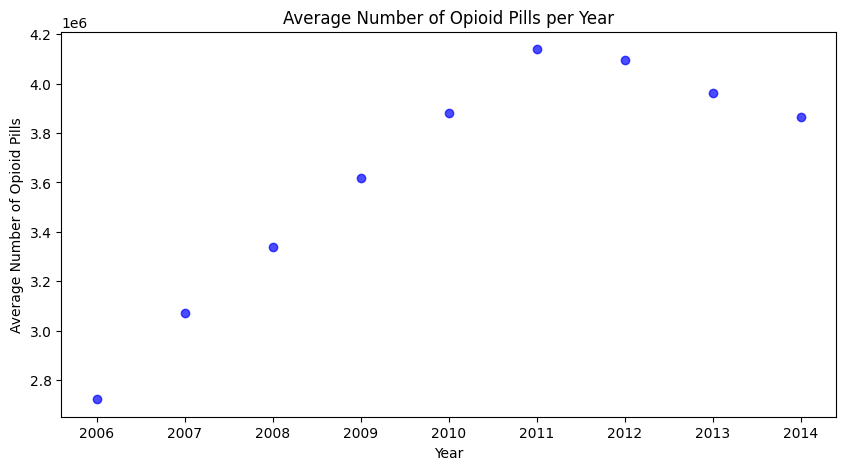

In [ ]:
# connect to SQLite database
db_path = "opioid.db"  # Make sure this points to your actual database file
conn = sqlite3.connect(db_path)

# query: compute the average number of opioid pills per year
query = """
SELECT year, AVG(DOSAGE_UNIT) AS avg_pills
FROM annual
GROUP BY year
ORDER BY year;
"""
df = pd.read_sql(query, conn)

# close database connection
conn.close()

# plot scatterplot
plt.figure(figsize=(10, 5))
plt.scatter(df['year'], df['avg_pills'], color='blue', alpha=0.7)

# labels and title
plt.xlabel("Year")
plt.ylabel("Average Number of Opioid Pills")
plt.title("Average Number of Opioid Pills per Year")

# show plot
plt.show()


This section of code opens an sql3 connection and computes the average number of opioid pills per year, then completes the requested plot.

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving land_area.csv to land_area.csv
Saving opioid_data.csv to opioid_data.csv
Saving population_data.csv to population_data.csv


I imported the 3 .csv files to be used in the R code section.

In [ ]:
%%writefile opioid_cleaning.R
# load necessary libraries
library(dplyr)
library(readr)

# load the opioid prescription data
opioid_data <- read_csv("opioid_data.csv")
population_data <- read_csv("population_data.csv")
land_area <- read_csv("land_area.csv")

# fix missing FIPS codes for Montgomery, AR
opioid_data <- opioid_data %>%
  mutate(countyfips = ifelse(BUYER_STATE == "AR" & BUYER_COUNTY == "MONTGOMERY", "05097", countyfips))

# convert countyfips to character for merging
opioid_data$countyfips <- as.character(opioid_data$countyfips)
population_data$countyfips <- as.character(population_data$countyfips)
land_area$STCOU <- as.character(land_area$STCOU)

# rename STCOU to countyfips in land area data
land_area <- land_area %>% rename(countyfips = STCOU)

# remove rows where countyfips is missing
opioid_data <- opioid_data %>% filter(!is.na(countyfips) & countyfips != "NA")

# merge data
opioid_merged <- left_join(opioid_data, population_data, by = "countyfips") %>%
  left_join(land_area, by = "countyfips")

# save cleaned data
write_csv(opioid_merged, "opioid_cleaned.csv")


Writing opioid_cleaning.R


This section uses python to write R code to complete the same cleaning steps from above.

In [ ]:
# install rpy2 in case it's not installed
!pip install rpy2

# enable R in Colab
%load_ext rpy2.ipython

# run the R script
!Rscript opioid_cleaning.R



Attaching package: ‘dplyr’

The following objects are masked from ‘package:stats’:

    filter, lag

The following objects are masked from ‘package:base’:

    intersect, setdiff, setequal, union

New names:
• `` -> `...1`
Rows: 27758 Columns: 7
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (3): BUYER_COUNTY, BUYER_STATE, countyfips
dbl (4): ...1, year, count, DOSAGE_UNIT

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
New names:
• `` -> `...1`
Rows: 28265 Columns: 11
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
chr (6): BUYER_COUNTY, BUYER_STATE, countyfips, county_name, NAME, variable
dbl (5): ...1, STATE, COUNTY, year, population

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this 

In [ ]:
# load the cleaned dataset into a Pandas DataFrame
df = pd.read_csv("opioid_cleaned.csv")

# display the first few rows
df.head()


,...1.x,BUYER_COUNTY.x,BUYER_STATE.x,year.x,count,DOSAGE_UNIT,countyfips,...1.y,BUYER_COUNTY.y,BUYER_STATE.y,...,LND110210N1,LND110210N2,LND210190F,LND210190D,LND210190N1,LND210190N2,LND210200F,LND210200D,LND210200N1,LND210200N2
0,1,ABBEVILLE,SC,2006,877,363620.0,45001,2313.0,ABBEVILLE,SC,...,0.0,0.0,0.0,3.05,0.0,0.0,0.0,3.02,0.0,0.0
1,1,ABBEVILLE,SC,2006,877,363620.0,45001,5455.0,ABBEVILLE,SC,...,0.0,0.0,0.0,3.05,0.0,0.0,0.0,3.02,0.0,0.0
2,1,ABBEVILLE,SC,2006,877,363620.0,45001,8597.0,ABBEVILLE,SC,...,0.0,0.0,0.0,3.05,0.0,0.0,0.0,3.02,0.0,0.0
3,1,ABBEVILLE,SC,2006,877,363620.0,45001,11737.0,ABBEVILLE,SC,...,0.0,0.0,0.0,3.05,0.0,0.0,0.0,3.02,0.0,0.0
4,1,ABBEVILLE,SC,2006,877,363620.0,45001,14877.0,ABBEVILLE,SC,...,0.0,0.0,0.0,3.05,0.0,0.0,0.0,3.02,0.0,0.0


I finished the assignment by loading the proper packages to be able to run the R code written in previous blocks. I then used it to create an R file of the cleaned data.